## Problem 5.1 - Performance for Polynomial Regression I

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
# defining the function f(x)
def f(x):
    if (x.any() < -1 or x.any() > 1):
        print("cosh(x) is undefined")
        return NaN
    else:
        return np.cosh(x)

In [7]:
# defining variables for the train data
n_values = np.round(np.power(10,np.linspace(1,5,10))).astype(int)
sigma = 0.3
k = 5
d = k + 1
np.random.seed(42)

In [ ]:
# estimating the LSR for different n
errors = []
for n in n_values:
    x = np.random.uniform(-1, 1, n)
    poly = PolynomialFeatures(degree = k)
    x_poly = poly.fit_transform(x.reshape(-1, 1))

    outer_risks = []
    for _ in range(100):
        y = f(x) + np.random.normal(0, sigma, n)
        model = LinearRegression(fit_intercept = False)
        model.fit(x_poly, y)
        y_pred = model.predict(x_poly)

        inner_risks = []
        for _ in range(100):
            y_test = f(x) + np.random.normal(0, sigma, n)
            risk = mean_squared_error(y_test, y_pred) 
            inner_risks.append(risk)
        
        outer_risks.append(np.mean(inner_risks))
    estimated_lsr = np.mean(outer_risks)
    errors.append(estimated_lsr - sigma**2)

In [ ]:
# calculate theorietical errors
theoretical_errors = [ (sigma**2 * d) / n for n in n_values ]

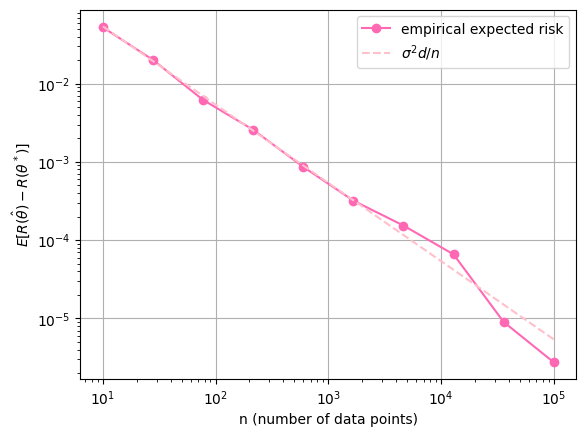

In [11]:
plt.figure()
plt.loglog(n_values, errors, marker = 'o', label = 'empirical expected risk', color = 'hotpink')
plt.loglog(n_values, theoretical_errors, label=r'$\sigma^2 d / n$', linestyle = '--', color = 'pink')
plt.xlabel('n (number of data points)')
plt.ylabel(r'$E[R(\hat\theta) - R(\theta^*)]$')
plt.legend()
plt.grid()
plt.show()

Observations:  
We can see that the empirical estimate of $E[R(\hat\theta) - R(\theta^*)]$ follows the theoretical curve $\sigma^2 d / n$ very closely.